In [63]:
import sys

!{sys.executable} -m pip install numpy
!{sys.executable} -m pip install librosa
!{sys.executable} -m pip install ruptures
!{sys.executable} -m pip install matplotlib

# Imports
import librosa as lb
import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

DEPRECATION: Loading egg at /Users/shivamenta/.local/share/virtualenvs/automatic-cuepoints-x8AZaZvf/lib/python3.12/site-packages/sqlcipher3-0.5.4-py3.12-macosx-15.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
DEPRECATION: Loading egg at /Users/shivamenta/.local/share/virtualenvs/automatic-cuepoints-x8AZaZvf/lib/python3.12/site-packages/sqlcipher3-0.5.4-py3.12-macosx-15.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
DEPRECATION: Loading egg at /Users/shivamenta/

In [64]:
# Constants
song_file_path = "/Users/shivamenta/Music/Music/Media.localized/Music/LMFAO/Sorry for Party Rocking (Deluxe Version)/04 Sexy and I Know It.m4a"
FREQUENCY_BUCKETS = [(0, 200), (201, 600), (601, 3000), (3001, 7000), (7001, 22000)]

STFT Change Point Detection

In [65]:
y, sr = lb.load(song_file_path, sr=None)
stft_result = lb.stft(y, n_fft=2048, hop_length=512)
magnitude = np.abs(stft_result)
freqs = lb.fft_frequencies(sr=sr)

freq_bucket_to_signal = [[] for _ in range(len(FREQUENCY_BUCKETS))]
num_time_slices = stft_result.shape[1]

for t in range(num_time_slices):
    for i, (lower, upper) in enumerate(FREQUENCY_BUCKETS):
        freq_indices = np.where((freqs >= lower) & (freqs <= upper))[0]
        bucket_intensity = np.sum(magnitude[freq_indices, t])
        freq_bucket_to_signal[i].append(bucket_intensity)


# Smooth Out Signal
def moving_average(x, w):
    return np.convolve(x, np.ones(w), "valid") / w


for idx, bucket in enumerate(freq_bucket_to_signal):
    np_arr = np.array(bucket)
    freq_bucket_to_signal[idx] = moving_average(np_arr, 200)

/var/folders/tp/r0xnlnps579f1f94fqm3jzsh0000gn/T/ipykernel_27294/3346310578.py:1: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = lb.load(song_file_path, sr=None)
/Users/shivamenta/.local/share/virtualenvs/automatic-cuepoints-x8AZaZvf/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


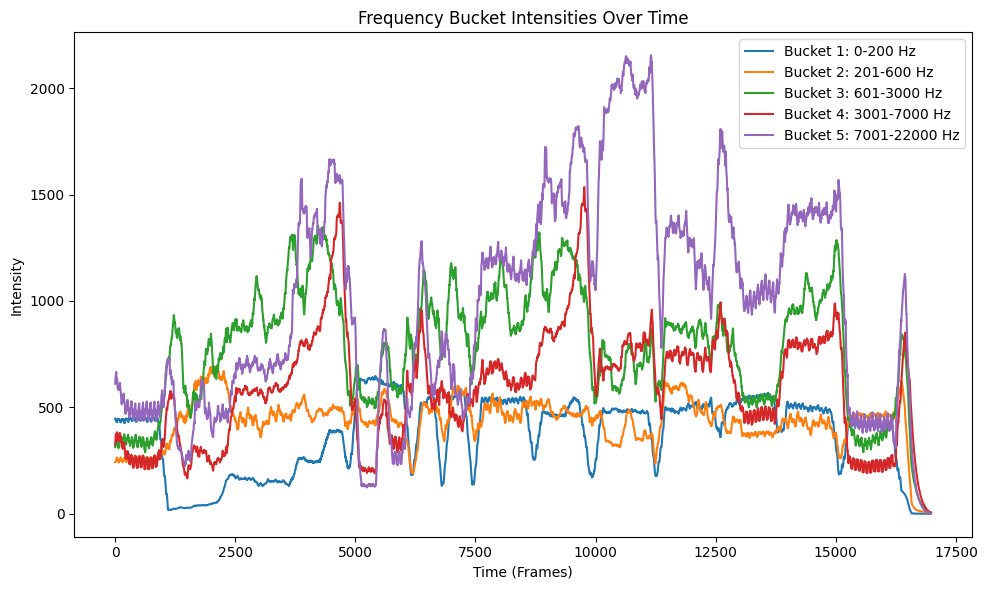

In [66]:
def plot_frequency_buckets(change_points=[]):
    plt.figure(figsize=(10, 6))

    # Plot each frequency bucket's intensity over time
    for i, bucket in enumerate(freq_bucket_to_signal):
        plt.plot(
            bucket,
            label=f"Bucket {i+1}: {FREQUENCY_BUCKETS[i][0]}-{FREQUENCY_BUCKETS[i][1]} Hz",
        )

    # Label the axes and add a title
    plt.xlabel("Time (Frames)")
    plt.ylabel("Intensity")
    plt.title("Frequency Bucket Intensities Over Time")

    for cp in change_points:
        plt.axvline(
            x=cp,
            color="red",
            linestyle="--",
            label="Change Point" if cp == change_points[0] else "",
        )

    # Add a legend to distinguish the different frequency buckets
    plt.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()


# Plot the results
plot_frequency_buckets()

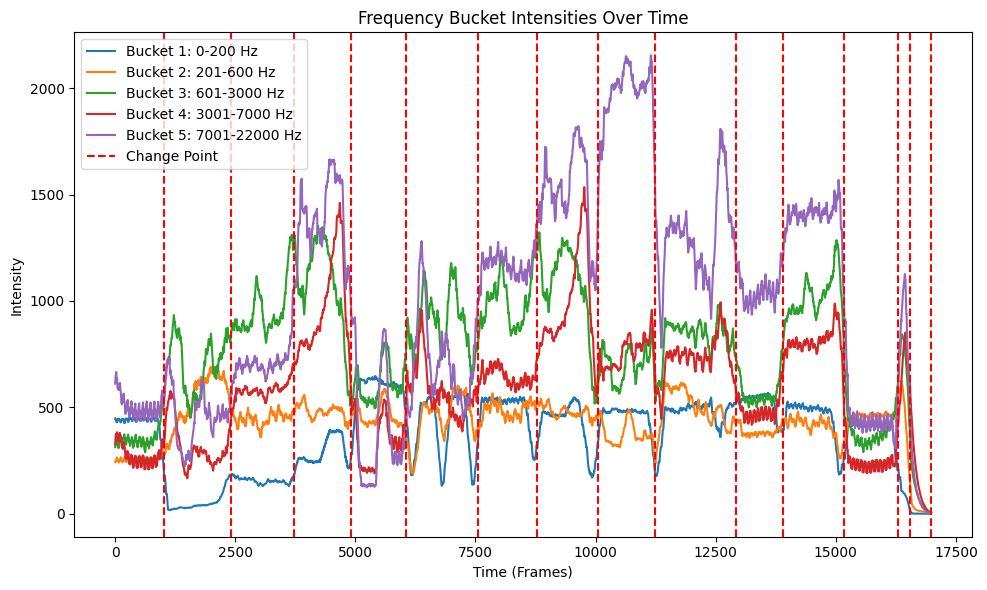

[np.int32(1021), np.int32(2405), np.int32(3720), np.int32(4901), np.int32(6062), np.int32(7556), np.int32(8781), np.int32(10051), np.int32(11235), np.int32(12922), np.int32(13895), np.int32(15175), np.int32(16293), np.int32(16549), 16983]


In [67]:
# 200 100000000
mat = np.array(freq_bucket_to_signal).T
model = rpt.KernelCPD(kernel="linear", min_size=157).fit(mat)
change_points = model.predict(pen=100000000)

plot_frequency_buckets(change_points)
print(change_points)

Tempogram Change Point Detection